# Scatterplots and correlation

On a hot Melbourne afternoon, half a million air conditioners switch on at once — and the state's electricity grid feels it immediately. Does temperature *cause* demand to move, or is the link more subtle?

In this lesson you will:

- load half-hourly Victorian electricity demand and temperature from the `vic_elec` dataset;
- plot two related time series on stacked panels and read Southern-Hemisphere seasonality;
- build **scatterplots** — including a colour trick that separates weekdays, weekends, and holidays;
- compute the **correlation coefficient** and see why it can mislead;
- explore several variables at once with a **scatterplot matrix**; and
- go beyond linear correlation with **Chatterjee's xi** ($\xi$).

Adapted from [Forecasting: Principles and Practice (3rd ed), §2.6](https://otexts.com/fpp3/scatterplots.html).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chatterjeexi

# Docs: https://pandas.pydata.org/docs/ | https://numpy.org/doc/stable/ | https://seaborn.pydata.org/ | https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chatterjeexi.html
sns.set_theme(style="whitegrid")

LESSON_DIR = Path().resolve()
DATA_DIR = LESSON_DIR.parent / "data"

## The `vic_elec` dataset

- Half-hourly readings from 2012 to 2015 (about 52,608 rows), stored as a plain CSV in `data/vic_elec.csv`.
- `Demand`: electricity demand for Victoria, Australia (labelled GW in FPP3 plots).
- `Temperature`: Melbourne temperature in degrees Celsius.
- `Holiday`: whether the calendar day is a public holiday.
- `Date`: calendar date.

Loading steps, each a standard pandas pattern you can reuse on any timestamped CSV:

- [`pd.read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) with `parse_dates` turns text columns into datetimes, and `index_col` makes the timestamp the index — which unlocks `.index.year`-style filtering.
- The file stores UTC clock times, so we localise to UTC and convert to Melbourne time; otherwise "summer afternoon" readings would appear at the wrong hours.
- We filter to **2014** only — the year used in the textbook example.
- [`np.select`](https://numpy.org/doc/stable/reference/generated/numpy.select.html) labels each row `Holiday`, `Weekend`, or `Weekday` — a general recipe for deriving a category from prioritised conditions.

In [2]:
vic_elec = pd.read_csv(
    DATA_DIR / "vic_elec.csv",
    parse_dates=["Time", "Date"],  # parse text columns into datetime64
    index_col="Time",              # timestamp index enables .index.year filtering below
)

# Timestamps in the CSV are UTC; convert to local Melbourne clock time,
# then drop the timezone so matplotlib treats them as plain datetimes.
vic_elec.index = (
    vic_elec.index.tz_localize("UTC")
    .tz_convert("Australia/Melbourne")
    .tz_localize(None)
)

vic_elec_2014 = vic_elec.loc[vic_elec.index.year == 2014].copy()

# np.select checks conditions top-to-bottom, so a holiday that falls on a
# Saturday is still labelled "Holiday". dayofweek: Monday=0 ... Sunday=6.
vic_elec_2014["DayType"] = np.select(
    [vic_elec_2014["Holiday"], vic_elec_2014.index.dayofweek >= 5],
    ["Holiday", "Weekend"],
    default="Weekday",
)

display(vic_elec_2014.head())
print(f"{len(vic_elec_2014):,} half-hourly observations in 2014")

,Demand,Temperature,Date,Holiday,DayType
Time,,,,,
2014-01-01 00:00:00,4091.593434,18.7,2014-01-01,True,Holiday
2014-01-01 00:30:00,4198.398912,18.1,2014-01-01,True,Holiday
2014-01-01 01:00:00,3914.647130,18.2,2014-01-01,True,Holiday
2014-01-01 01:30:00,3672.549608,17.9,2014-01-01,True,Holiday
2014-01-01 02:00:00,3497.539030,17.6,2014-01-01,True,Holiday


17,520 half-hourly observations in 2014


## Two time series for 2014

Stacked time plots let us read each series separately:

- **Summer** (January–February in Australia) — high temperatures and high demand (air-conditioning).
- **Winter** (June–August) — cold months with a second demand peak (heating).
- **Spring and autumn** — milder weather and lower extremes.

Note the **horizontal y-axis labels** at the top of each panel — the same layout as the textbook figure.

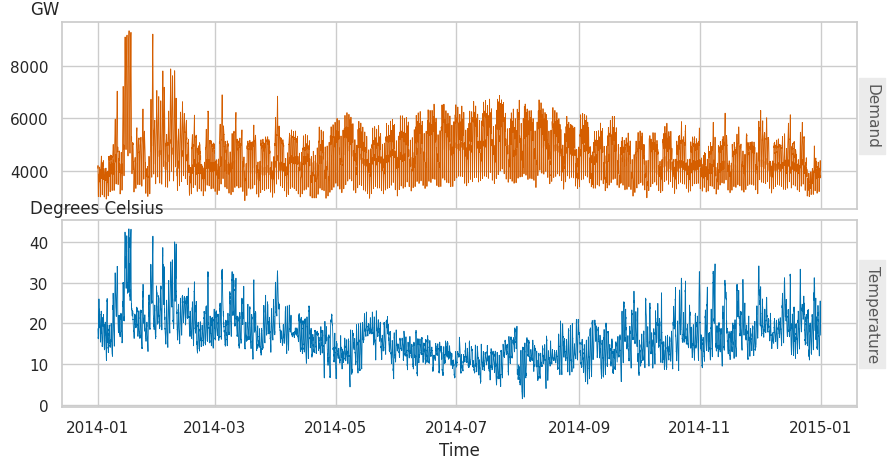

In [3]:
panels = [
    ("Demand", "GW", "#D55E00"),
    ("Temperature", "Degrees Celsius", "#0072B2"),
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 5),
    sharex=True,  # stacked panels share the time axis, so peaks line up vertically
)

# One panel per series: works for any number of columns you want to compare over time.
for axis, (column, ylabel, color) in zip(axes, panels):
    sns.lineplot(
        x=vic_elec_2014.index,
        y=vic_elec_2014[column],
        ax=axis,
        color=color,
        linewidth=0.6,
    )
    axis.set_ylabel(
        ylabel,
        rotation=0,
        ha="left",
        va="bottom",
    )
    axis.yaxis.set_label_coords(-0.04, 1.02)
    axis.set_xlabel("")
    axis.text(
        1.01,
        0.5,
        column,
        transform=axis.transAxes,
        rotation=270,
        va="center",
        ha="left",
        fontsize=11,
        color="0.35",
        backgroundcolor="0.92",
    )

axes[-1].set_xlabel("Time")
fig.subplots_adjust(hspace=0.06, right=0.92)
plt.show()

## Scatterplot: demand versus temperature

Plotting demand on the *y*-axis against temperature on the *x*-axis reveals a **non-linear U-shape**:

- hot days → air-conditioning loads;
- cold days → heating loads.

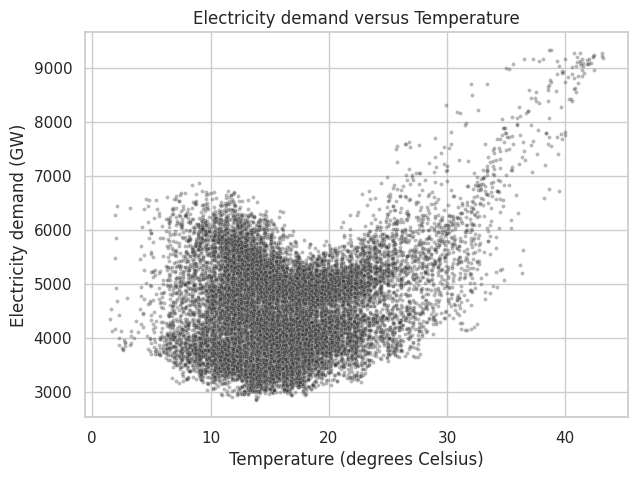

In [4]:
fig, axis = plt.subplots(figsize=(7, 5))

# Convention: put the suspected driver (temperature) on x and the response (demand) on y.
sns.scatterplot(
    data=vic_elec_2014,
    x="Temperature",
    y="Demand",
    s=8,          # small markers: 17k+ points would otherwise blur into a blob
    alpha=0.35,   # transparency reveals density where points overlap
    color="#333333",
    ax=axis,
)

axis.set(
    title="Electricity demand versus Temperature",
    xlabel="Temperature (degrees Celsius)",
    ylabel="Electricity demand (GW)",
)
plt.show()

## Colour by day type

The dataset includes a `Holiday` flag. We also distinguish **weekdays** (Monday–Friday) from **weekends** (Saturday–Sunday) and colour the points accordingly.

- **Weekends** (green) sit below **weekdays** at the same temperature — offices and factories are off.
- **Holidays** (pink) cluster with weekends — similar low-demand behaviour.
- The U-shaped temperature pattern is the same for every day type.

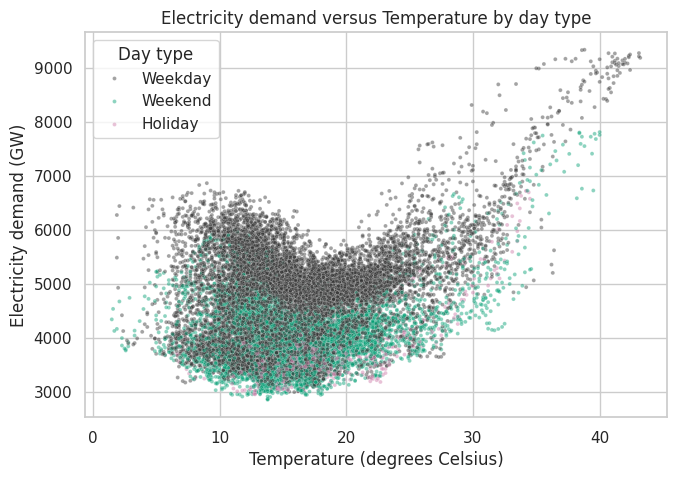

In [5]:
day_type_palette = {
    "Weekday": "#333333",
    "Weekend": "#009E73",
    "Holiday": "#CC79A7",
}

fig, axis = plt.subplots(figsize=(7.5, 5))

# The same scatterplot, split by a categorical column. This hue pattern works
# for any grouping you can express as a column (region, product, regime, ...).
sns.scatterplot(
    data=vic_elec_2014,
    x="Temperature",
    y="Demand",
    hue="DayType",                                # colour encodes the category
    hue_order=["Weekday", "Weekend", "Holiday"],  # fixes legend and colour assignment order
    palette=day_type_palette,
    s=8,
    alpha=0.45,
    ax=axis,
)

axis.set(
    title="Electricity demand versus Temperature by day type",
    xlabel="Temperature (degrees Celsius)",
    ylabel="Electricity demand (GW)",
)
axis.legend(title="Day type", loc="upper left")
plt.show()

## Correlation coefficient

The Pearson correlation $r$ measures **linear** association:

$$r = \frac{\sum_{t=1}^{T} (x_t - \bar{x})(y_t - \bar{y})}{\sqrt{\sum_{t=1}^{T} (x_t - \bar{x})^2}\,\sqrt{\sum_{t=1}^{T} (y_t - \bar{y})^2}}$$

- $r$ is always between $-1$ and $+1$.
- $r \approx 0$ does *not* mean "no relationship" — only that the relationship is not well described by a straight line.
- Correlation describes association, not **causation**.

In [6]:
# Series.corr computes Pearson r by default — a purely *linear* measure.
correlation = vic_elec_2014["Demand"].corr(vic_elec_2014["Temperature"])
print(f"Pearson r = {correlation:.2f}")
print("The U-shaped scatterplot shows a stronger pattern than this linear measure suggests.")

Pearson r = 0.28
The U-shaped scatterplot shows a stronger pattern than this linear measure suggests.


## Scatterplot matrix: US macro variables

When several time series may be related, plot every pair at once. The `us_change` dataset — a plain CSV in `data/us_change.csv` — contains quarterly percentage changes in:

- consumption,
- income,
- production,
- savings, and
- unemployment.

We build the matrix with [seaborn](https://seaborn.pydata.org/generated/seaborn.PairGrid.html)'s `PairGrid`:

- lower triangle → scatterplots;
- upper triangle → correlation coefficients;
- diagonal → density curves.

In [7]:
us_change = pd.read_csv(DATA_DIR / "us_change.csv")

# Quarters are stored as strings like "1970Q1"; PeriodIndex understands that
# format directly — the same recipe works for any quarterly or monthly CSV.
us_change["Quarter"] = pd.PeriodIndex(us_change["Quarter"], freq="Q")

macro_vars = [
    "Consumption",
    "Income",
    "Production",
    "Savings",
    "Unemployment",
]

display(us_change[macro_vars].head())

,Consumption,Income,Production,Savings,Unemployment
0,0.618566,1.044801,-2.452486,5.299014,0.9
1,0.451984,1.225647,-0.551459,7.789894,0.5
2,0.872872,1.585154,-0.358652,7.403984,0.5
3,-0.271848,-0.239545,-2.185691,1.169898,0.7
4,1.901345,1.975925,1.909764,3.535667,-0.1


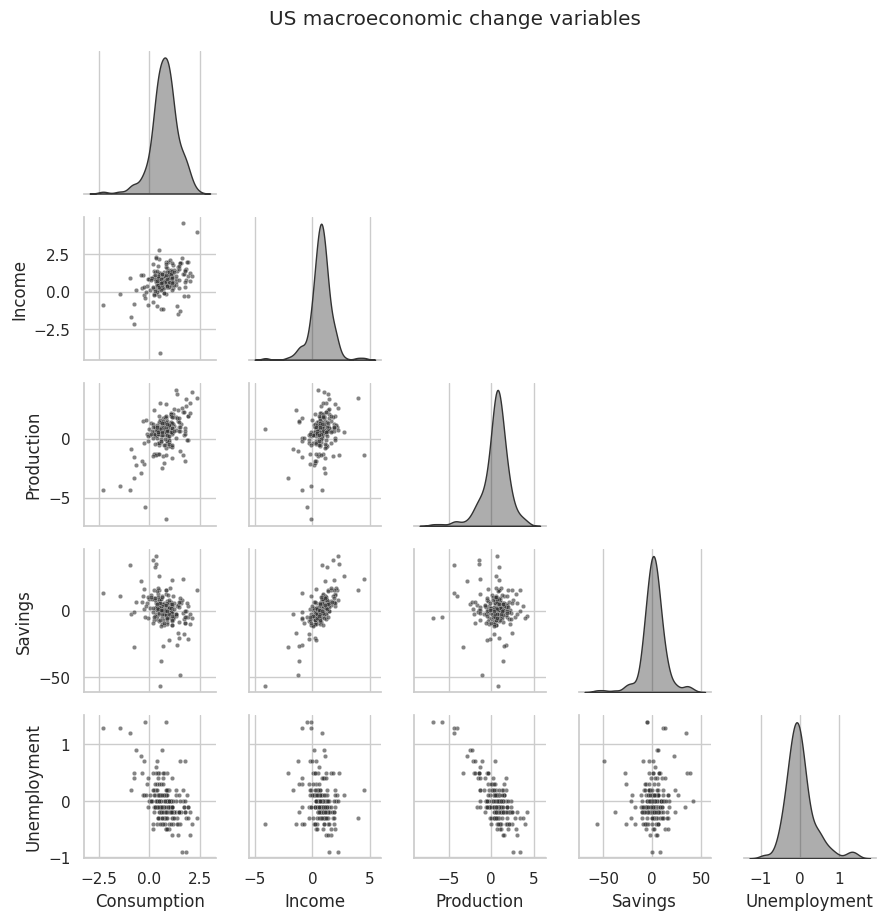

In [8]:
def corr_label(x, y, **kwargs):
    """Write the Pearson r in the upper triangle of a PairGrid."""
    del kwargs
    axis = plt.gca()
    r_value = x.corr(y)
    axis.text(
        0.5,
        0.5,
        f"{r_value:.2f}",
        transform=axis.transAxes,
        ha="center",
        va="center",
        fontsize=10,
    )
    axis.set_axis_off()


grid = sns.PairGrid(
    us_change,
    vars=macro_vars,
    corner=True,
    diag_sharey=False,
    height=1.8,
)
grid.map_lower(
    sns.scatterplot,
    s=10,
    alpha=0.6,
    color="#333333",
)
grid.map_upper(corr_label)
grid.map_diag(
    sns.kdeplot,
    fill=True,
    color="#333333",
    alpha=0.4,
)
grid.fig.suptitle("US macroeconomic change variables", y=1.02)
plt.show()

### Reading the matrix

Strong **positive** correlations:

- production and consumption — when output rises, spending tends to rise;
- savings and income — higher-income quarters tend to save more.

Strong **negative** correlations:

- consumption and unemployment — as unemployment rises, consumption falls;
- production and unemployment — higher output goes with lower unemployment.

The diagonal shows distributional features too: unemployment is positively skewed — most quarters have low unemployment with a long tail of high values.

In [9]:
display(us_change[macro_vars].corr().round(2))

,Consumption,Income,Production,Savings,Unemployment
Consumption,1.00,0.38,0.53,-0.26,-0.53
Income,0.38,1.00,0.27,0.72,-0.22
Production,0.53,0.27,1.00,-0.06,-0.77
Savings,-0.26,0.72,-0.06,1.00,0.11
Unemployment,-0.53,-0.22,-0.77,0.11,1.00


## Beyond linear correlation: Chatterjee's xi

Recall the **problem** with demand versus temperature: the relationship is U-shaped, yet Pearson $r = 0.28$ made it look weak. Correlation only sees *straight lines*.

**Chatterjee's xi** ($\xi$) asks a different question: *how strong is the association between $x$ and $y$, including non-linear and non-monotonic patterns?*

- $\xi$ is a coefficient of **dependence** — it measures strength of association, not direction.
- Values lie approximately between **0** (independent) and **1** (perfect functional dependence).
- Unlike Pearson $r$, $\xi$ can detect **non-linear** and **non-monotonic** patterns (such as the U-shaped demand–temperature curve).
- Unlike correlation, $\xi$ is **asymmetric**: $\xi(x, y) \neq \xi(y, x)$ — the order of variables matters.

We use [`scipy.stats.chatterjeexi`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chatterjeexi.html).

In [10]:
temperature = vic_elec_2014["Temperature"]
demand = vic_elec_2014["Demand"]

xi_temp_demand = chatterjeexi(temperature, demand).statistic
xi_demand_temp = chatterjeexi(demand, temperature).statistic

print(f"Pearson r (symmetric)           = {correlation:.2f}")
print(f"Chatterjee xi Temperature -> Demand = {xi_temp_demand:.2f}")
print(f"Chatterjee xi Demand -> Temperature  = {xi_demand_temp:.2f}")

Pearson r (symmetric)           = 0.28
Chatterjee xi Temperature -> Demand = 0.34
Chatterjee xi Demand -> Temperature  = 0.06


Two things stand out:

- The scores are **asymmetric**. Temperature carries more information about demand than demand carries about temperature — consistent with temperature driving heating and cooling loads.
- $\xi \approx 0.34$ is **higher than** $r = 0.28$, reflecting the U-shaped pattern that linear correlation understates. The reverse direction ($\xi \approx 0.06$) is much weaker.

## Chatterjee's xi matrix

Just like a correlation matrix, we can compute $\xi$ for **every ordered pair** of variables. Because $\xi$ is directional, the matrix is **not symmetric** — cell $(i, j)$ is $\xi(x_i, y_j)$.

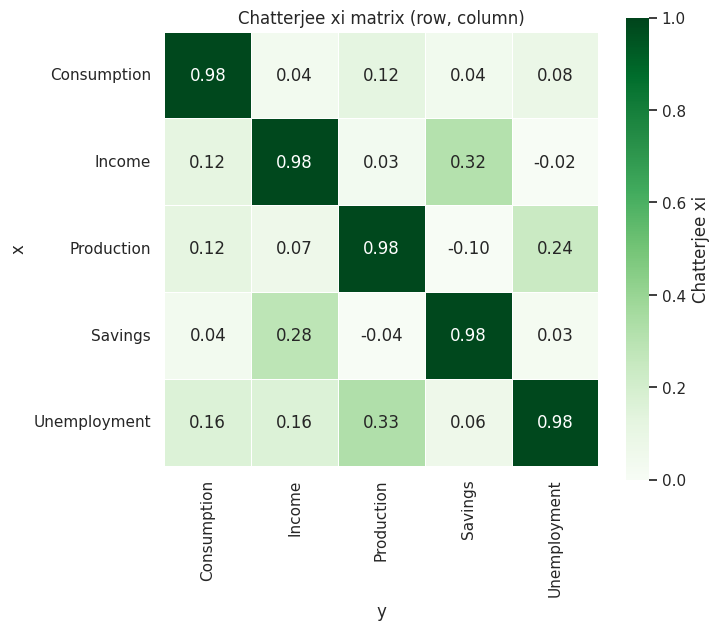

In [11]:
xi_grid = pd.DataFrame(index=macro_vars, columns=macro_vars, dtype=float)

for row in macro_vars:
    for col in macro_vars:
        xi_grid.loc[row, col] = chatterjeexi(
            us_change[row],
            us_change[col],
        ).statistic

fig, axis = plt.subplots(figsize=(7, 6))

sns.heatmap(
    xi_grid,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Chatterjee xi"},
    ax=axis,
)

axis.set(
    title="Chatterjee xi matrix (row, column)",
    xlabel="y",
    ylabel="x",
)
plt.show()

### Reading the matrix

Compare this matrix to the Pearson correlation matrix above — $\xi$ measures **strength of association**, not sign:

- **Production** and **Unemployment** had $r \approx -0.77$, but $\xi \approx 0.24$–$0.33$ — a strong negative linear link still shows up as moderate association strength.
- **Savings** and **Income** had $r \approx 0.72$; the corresponding $\xi$ cells ($0.28$–$0.32$) are also among the highest in the matrix.
- **Unemployment → Production** ($\xi \approx 0.33$) exceeds **Production → Unemployment** ($\xi \approx 0.24$) — the same pair of variables, but association strength runs mostly one way.

**Correlation and Chatterjee's xi measure different things.** Use $r$ to describe *linear association* (including sign), and $\xi$ when you suspect *non-linear* or *non-monotonic* dependence — and, as always, **plot the data first**.

### Reusing these recipes

- To explore a *new* multivariate dataset, keep the same three steps: `PairGrid` for the scatterplot matrix, `.corr()` for the linear summary, and a `chatterjeexi` double loop for directional dependence.
- The heatmap cell works for any square matrix of scores — swap `xi_grid` for `.corr()` output (with `cmap="RdBu_r"`, `vmin=-1`, `center=0` since $r$ is signed).